# Computational oncology project combining multi-omics data, unsupervised learning, and survival analysis to study tumor heterogeneity.

## Multi-omics Tumor Subtyping in TCGA-BRCA

### Objective

### Data

### Set-up

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from lifelines import KaplanMeierFitter
import os

### 1. Load Data

In [9]:
expr = pd.read_csv("TCGA.BRCA.sampleMap_HiSeqV2.gz", sep="\t", index_col=0)
mutation = pd.read_csv("mc3.v0.2.8.PUBLIC.xena", sep="\t", comment='#')
clinical = pd.read_csv("TCGA-BRCA.clinical.tsv", sep="\t")

### 2. Preprocessing & Alignment

In [11]:
# RNA: transpose to patient × gene and standardize IDs
expr = expr.T
expr.index = expr.index.str[:12]
expr = expr[~expr.index.duplicated()]

# Mutation: standardize IDs
mutation['sample'] = mutation['sample'].astype(str).str.strip().str[:12]

# Clinical: build survival variables
clinical['patient_id'] = clinical['submitter_id'].str[:12]
clinical = clinical.set_index('patient_id')

clinical['time'] = clinical['days_to_death.demographic'].fillna(
    clinical['days_to_last_follow_up.diagnoses']
)
clinical['event'] = clinical['vital_status.demographic'].map({'Dead': 1, 'Alive': 0})

# Align patients
common = list(set(expr.index) & set(mutation['sample']) & set(clinical.index))

expr = expr.loc[common]
clinical = clinical.loc[common]

### 3. Tumor Subtyping (Clustering)

In [13]:
# Select top variable genes
gene_variance = expr.var(axis=0)
top_genes = gene_variance.sort_values(ascending=False).head(2000).index
expr_subset = expr[top_genes]

# Scale data
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(expr_subset)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
expr['cluster'] = kmeans.fit_predict(expr_scaled)

expr['cluster'].value_counts()

cluster
3    321
0    243
2    154
1     71
Name: count, dtype: int64

### 4. Mutation Analysis

In [15]:
# Build mutation matrix (patient × gene)
mutation['mutated'] = 1

mut_matrix = mutation.pivot_table(
    index='sample',
    columns='gene',
    values='mutated',
    fill_value=0
)

# Align with expression clusters
common = list(set(expr.index) & set(mut_matrix.index))
expr = expr.loc[common]
mut_matrix = mut_matrix.loc[common]

# Add cluster labels
mut_matrix['cluster'] = expr['cluster']

# Mutation frequency per cluster
mutation_freq = mut_matrix.groupby('cluster').mean()

In [16]:
# Top mutations (example: cluster 0)
mutation_freq.T.sort_values(by=0, ascending=False).head(10)

cluster,0,1,2,3
gene,,,,
PIK3CA,0.337449,0.323944,0.077922,0.492212
TP53,0.209877,0.211268,0.870130,0.205607
TTN,0.209877,0.154930,0.272727,0.199377
GATA3,0.193416,0.126761,0.000000,0.133956
KMT2C,0.144033,0.056338,0.058442,0.102804
MUC16,0.115226,0.140845,0.116883,0.133956
MAP3K1,0.086420,0.126761,0.025974,0.105919
OBSCN,0.074074,0.084507,0.103896,0.043614
RYR2,0.074074,0.042254,0.077922,0.077882


In [ ]:
# Mutation Barplot 

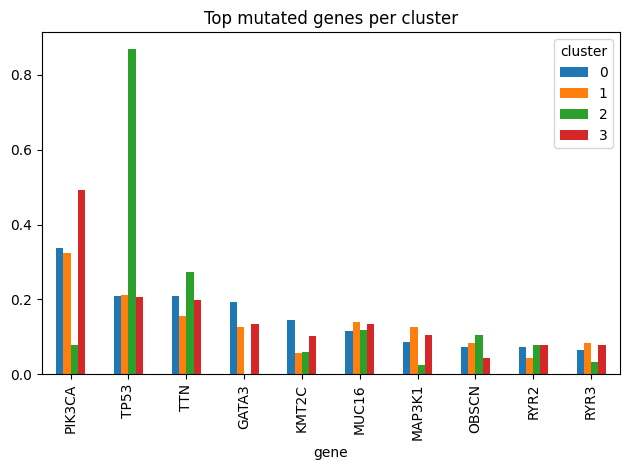

In [18]:
mutation_freq.T.sort_values(by=0, ascending=False).head(10).plot(kind='bar')
plt.title("Top mutated genes per cluster")
plt.tight_layout()
plt.savefig("figures/mutation_barplot.png")

### 5. Survival Analysis

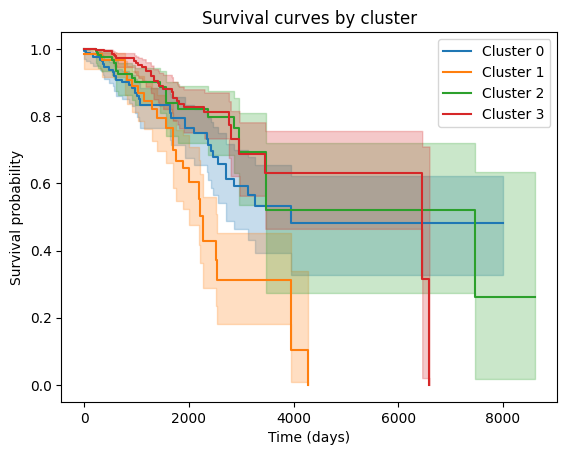

In [17]:
clinical['cluster'] = expr['cluster']

kmf = KaplanMeierFitter()

plt.figure()

for cluster in sorted(clinical['cluster'].dropna().unique()):
    ix = clinical['cluster'] == cluster
    
    kmf.fit(
        clinical.loc[ix, 'time'],
        clinical.loc[ix, 'event'],
        label=f"Cluster {cluster}"
    )
    
    kmf.plot()

plt.title("Survival curves by cluster")
plt.xlabel("Time (days)")
plt.ylabel("Survival probability")
plt.legend()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/kmf.png", dpi=300, bbox_inches='tight')

plt.show()

### 6. Key Insights

In [ ]:

1. A cluster enriched for TP53 mutations (~87%) indicates genomic instability
2. Another cluster shows PIK3CA-driven mutation patterns
3. A heterogeneous mutation cluster exhibits the worst survival, suggesting multi-factorial drivers of tumor aggressiveness

### Conclusion

Multi-omics integration reveals biologically meaningful tumor subtypes with distinct mutation profiles and clinical outcomes. 
Tumor aggressiveness appears to arise from complex genomic interactions rather than a single dominant mutation.